### **Assignment 2** ###
**24EE10087 Parth Sangale**

For a variable  x = [$x_1$, $x_2$, $x_3$, $x_4$]

The feature map consists of the terms of degree 0, 1 and 2 

Degree 0: 1

Degree 1 : $x_i$

Degree 2 : $x_i^2$ and $x_i$$x_j$

$\phi$(x)=[1     $x_1$  $x_2$  $x_3$  $x_4$  $x_1^2$  $x_2^2$  $x_3^2$  $x_4^2$  $x_1$$x_2$  $x_1$$x_3$  $x_1$$x_4$  $x_2$$x_3$  $x_2$$x_4$  $x_3$$x_4$]

Dimension of the feature map = 15

Model:

*f(w; x)*=$\Sigma$ $w_j$ $\phi_j$(x)  or  y=$w^T$$\phi$(x) where w has a dimension of 15


Cost function:
l(w) = $\Sigma$ ||$y_i$ - f(w; $x_i$)||$_2^2$

Linear regression problem:

min *l*(w)

3. Gradient of the Cost Function

   To find the gradient of the cost function $J(w)$ with respect to the decision variable $w$, we perform matrix differentiation on the cost function defined in Question 2.

   The Cost Function:$$J(w) = \| Y - \Phi w \|_2^2$$$$J(w) = (Y - \Phi w)^T (Y - \Phi w)$$Expanding the terms:$$J(w) = (Y^T - (\Phi w)^T) (Y - \Phi w)$$$$J(w) = (Y^T - w^T \Phi^T) (Y - \Phi w)$$$$J(w) = Y^T Y - Y^T \Phi w - w^T \Phi^T Y + w^T \Phi^T \Phi w$$Since $Y^T \Phi w$ is a scalar, it is equal to its transpose $(Y^T \Phi w)^T = w^T \Phi^T Y$.

    We can combine the middle terms:$$J(w) = Y^T Y - 2 w^T \Phi^T Y + w^T \Phi^T \Phi w$$Taking the gradient with respect to $w$ ($\nabla_w$):

   Using the standard matrix calculus identities:$\nabla_w (w^T A) = A$ (where $A = \Phi^T Y$)$\nabla_w (w^T A w) = 2Aw$ (where $A = \Phi^T \Phi$, which is symmetric)$$\nabla_w J(w) = 0 - 2 \Phi^T Y + 2 \Phi^T \Phi w$$

In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import scipy

### Generating a Feature Matrix ###

The function below generates a feature matrix for any matrix X when the cost function is a 2nd degree polynomial 



In [3]:
def get_feature_matrix(X):
    N, d = X.shape
    features = []
    features.append(np.ones(N))
    for i in range(d):
        features.append(X[:, i])
    # Square
    for i in range(d):
        features.append(X[:, i]**2)
        
    # Cross-product terms
    for i in range(d):
        for j in range(i + 1, d):
            features.append(X[:, i] * X[:, j])
            
    return np.vstack(features).T

In [4]:
def grad_f(phi, Y, w): #Gradient
    return 2*phi.T @ (phi @ w - Y)

In [5]:
def cost_f(phi, Y, w): #Cost Function
    return np.sum((Y-phi @ w)**2)

In [6]:
def cost_reg(phi, Y, w, l): #Cost Function Regularized
    return np.sum((Y-phi@w)**2) + l*np.sum((w)**2)

In [7]:
data=scipy.io.loadmat("Week2_DataSet.mat")
X=data['X'].T #Reshape the matrix
Y=data['Y'].flatten() #Convert into a 1D arrray of size 100

In [8]:
phi = get_feature_matrix(X)

In [27]:
X.shape

(100, 4)

In [28]:
Y.shape

(100,)

In [10]:
print(X) 
print(Y) 
print(phi)

[[-9.75908025  9.65751723 -9.79531383  7.44822813]
 [-5.20710227 -2.6048318   2.09955618  1.59568165]
 [-2.71072329  8.56562506 -6.61423052  8.60346639]
 [ 6.93161133 -3.2851859  -5.16062614 -7.38378723]
 [ 7.14720402  0.26636163 -2.78007788  1.6718804 ]
 [-0.72005484  0.54589643 -7.20800222  2.20703376]
 [ 0.92394035  6.01635063  0.26708287 -2.72785004]
 [-4.46896381  2.45209979  1.24980402  5.87344825]
 [ 8.90259961 -3.51259283 -5.90856928  8.14208051]
 [ 3.21234634  6.19480633  8.27552723  8.01056827]
 [-5.71099207 -6.69150782 -1.13985625  3.62643738]
 [ 8.9160108   4.57037334 -0.69811975  1.70152343]
 [-4.84945867  8.70366958 -1.45538186  9.96751688]
 [-6.28574032  0.56069139  1.17961925 -6.31710427]
 [ 1.91481549 -4.22956275 -6.02139249  7.50229346]
 [ 6.14729401 -4.52646597 -7.30400721 -8.10821484]
 [-7.68497532 -6.73334089 -5.52924318 -5.71456153]
 [ 8.95646221  5.56213988  0.2449078  -8.44889795]
 [-0.16399797  0.82494781  7.46112217 -4.39960316]
 [-7.02990803  8.045453   -0.47

### Finding optimal weight ###

In [30]:
n_features=phi.shape[1]
w = cp.Variable(n_features)
cost = cp.sum_squares(Y - phi @ w)
prob = cp.Problem(cp.Minimize(cost))
prob.solve()

w_star = w.value
print("Optimal Weights:", w_star)

Optimal Weights: [-1.08989174e-14 -5.85130164e-16  5.00000000e+00 -4.08709012e-15
 -2.98022216e-15 -2.00000000e+00  1.94112442e-16  4.55470193e-16
  3.28221676e-16 -6.63875483e-16  7.00000000e+00  9.49273996e-16
  5.30334034e-16 -7.01501890e-16  1.60000000e+01]


### Checking Error Visually ###

(array([ 2.,  0.,  0.,  0.,  0.,  6.,  0.,  0.,  0.,  0., 20.,  3.,  5.,
         5.,  4., 20., 11., 12.,  1.,  0.,  5.,  0.,  1.,  0.,  0.,  3.,
         0.,  1.,  0.,  1.]),
 array([-3.41060513e-13, -3.18323146e-13, -2.95585778e-13, -2.72848411e-13,
        -2.50111043e-13, -2.27373675e-13, -2.04636308e-13, -1.81898940e-13,
        -1.59161573e-13, -1.36424205e-13, -1.13686838e-13, -9.09494702e-14,
        -6.82121026e-14, -4.54747351e-14, -2.27373675e-14,  0.00000000e+00,
         2.27373675e-14,  4.54747351e-14,  6.82121026e-14,  9.09494702e-14,
         1.13686838e-13,  1.36424205e-13,  1.59161573e-13,  1.81898940e-13,
         2.04636308e-13,  2.27373675e-13,  2.50111043e-13,  2.72848411e-13,
         2.95585778e-13,  3.18323146e-13,  3.41060513e-13]),
 <BarContainer object of 30 artists>)

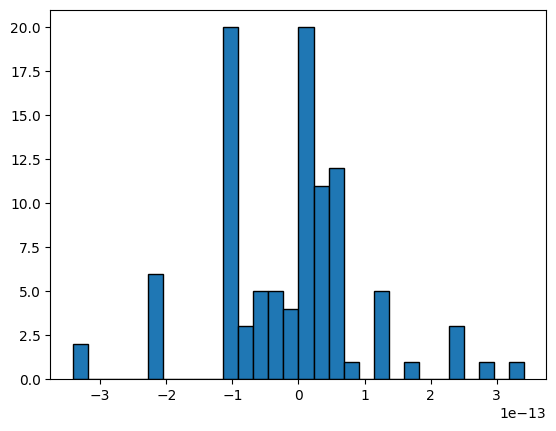

In [12]:
err=Y-phi @ w_star
plt.hist(err, edgecolor='black', bins=30)

In [13]:
def gradient_descent(w, T, eta, w_star, phi, Y): #Gradient Descent
    w_t=w.copy()
    f_gd=np.zeros(T)
    err=np.zeros(T)
    for i in range(T):
        f_gd[i]=cost_f(phi, Y, w_t)
        err[i]=np.linalg.norm(w_t-w_star, 2)
        w_t=w_t - eta*grad_f(phi, Y, w_t)
        
    return w_t, f_gd, err

In [14]:
def acc_grad(w, T, eta, w_star, phi, Y, kappa): #Accelerated Descent
    y_t=w.copy()
    w_t=w.copy()
    k1=(1 + (np.sqrt(kappa)-1)/(np.sqrt(kappa)+1))
    k2=(np.sqrt(kappa)-1)/(np.sqrt(kappa)+1)
    f_acc=np.zeros(T)
    err=np.zeros(T)
    for i in range(T):
        f_acc[i]=cost_f(phi, Y, w_t)
        err[i]=np.linalg.norm(w_t-w_star, 2)
        y_prev=y_t.copy()
        y_t=w_t-eta*grad_f(phi, Y, w_t)
        w_t=k1*y_t-k2*y_prev
    return w_t, f_acc, err    

In [15]:
def stoch_grad(w, T, eta, w_star, phi, Y): #Stochastic Gradient Descent
    N=Y.shape[0]
    w_t=w.copy()
    err=np.zeros(T)
    f_sgd=np.zeros(T)
    for j in range(T):
        i=np.random.randint(0, N)
        eta_i=eta
        err[j]=np.linalg.norm(w_t-w_star)
        f_sgd[j]=cost_f(phi, Y, w_t)
   
        phi_i=phi[i:i+1]
        y_i=Y[i:i+1]
        grad_i=grad_f(phi_i, y_i, w_t)
        w_t-=eta_i*grad_i
    return w_t, f_sgd, err

### Checking the weights obtained using Gradient Descent ###

The above 3 functions are run for an initial value of *w* and the output is compared with w*

In [16]:
w_init=np.zeros(w_star.shape[0])
Hess= 2*phi.T @ phi
eigenvals=np.linalg.eigvalsh(Hess)
beta=np.max(eigenvals)
alpha=np.min(eigenvals)

eta_gd=1/beta
T=1000
w_gd, f_gd, err_gd=gradient_descent(w_init, T, eta_gd, w_star, phi, Y)
print(w_gd)


[-3.12830409e-02  2.39205733e-02  4.95991686e+00  2.25277105e-02
 -5.85633224e-03 -2.00036097e+00  1.45664354e-03  2.10425328e-04
  8.24839297e-04 -2.12049915e-03  7.00207906e+00 -4.13707698e-04
 -3.38399633e-03  8.43359066e-04  1.59997719e+01]


In [17]:
eta_acc=1/beta
kappa=beta/alpha
w_acc, f_acc, err_acc=acc_grad(w_init, T, eta_acc, w_star, phi, Y, kappa)

print(w_acc)

[-8.70212244e-04  5.82707497e-04  4.99899745e+00  6.70498881e-04
 -2.45283609e-04 -2.00000795e+00  3.89187902e-05  4.09618242e-06
  2.43486683e-05 -5.46682864e-05  7.00005084e+00 -9.17404900e-06
 -8.83459508e-05  2.38460353e-05  1.59999902e+01]


In [18]:
eta_sgd=1e-5
w_sgd, f_sgd, err_sgd=stoch_grad(w_init, T, eta_sgd, w_star, phi, Y)
print(w_sgd)

[-1.57059966e-02 -7.55408914e-02  1.98026268e+00 -2.21224063e-01
 -6.55487709e-01 -2.08605413e+00 -8.63449271e-02 -9.57123126e-02
  1.83773437e-03 -4.82629024e-02  7.03433834e+00 -7.34823390e-03
 -1.35782410e-01  1.56174097e-01  1.59053157e+01]


### Visualising the errors ###

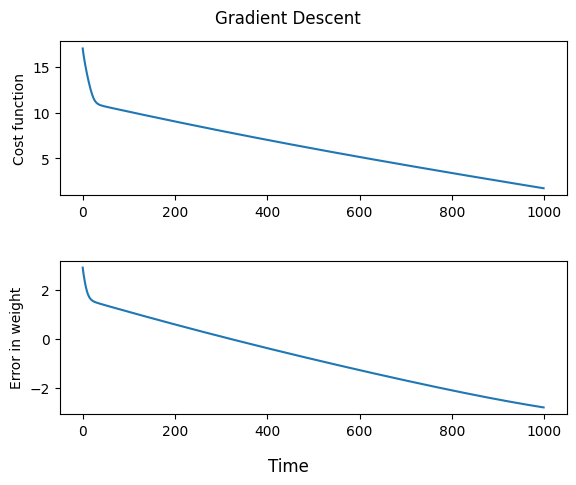

In [19]:
fig, (ax1, ax2)= plt.subplots(2, 1)
ax1.plot(np.log(f_gd))
ax1.set_ylabel("Cost function")
ax2.plot(np.log(err_gd))
ax2.set_ylabel("Error in weight")

plt.tight_layout(pad=3.0)
fig.supxlabel("Time")
fig.suptitle("Gradient Descent")
plt.show()

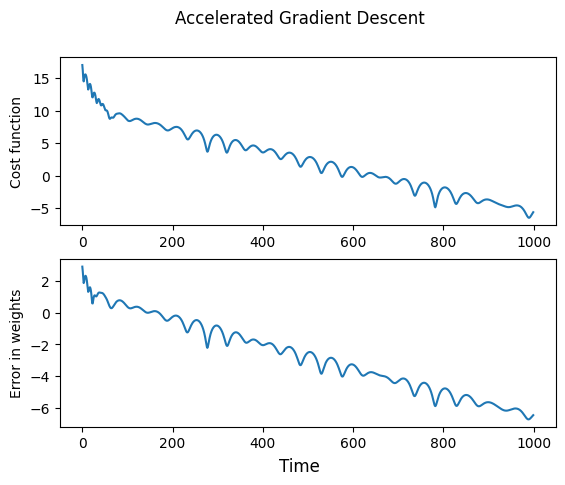

In [20]:
fig, (ax3, ax4) = plt.subplots(2, 1)
ax3.plot(np.log(f_acc))
ax3.set_ylabel("Cost function")
ax4.plot(np.log(err_acc))
ax4.set_ylabel("Error in weights")
fig.supxlabel("Time")
fig.suptitle("Accelerated Gradient Descent")
plt.show()

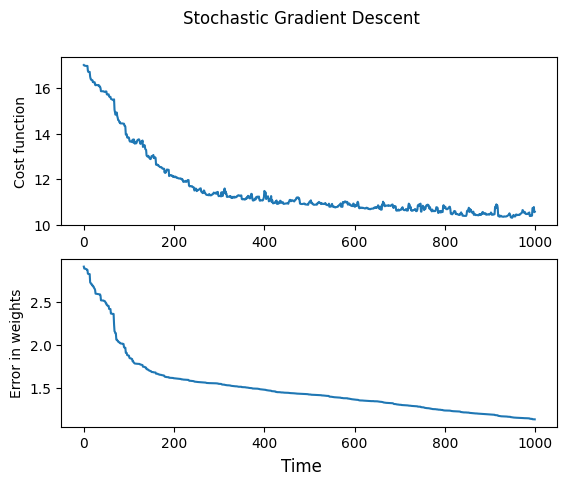

In [21]:
fig, (ax3, ax4) = plt.subplots(2, 1)
ax3.plot(np.log(f_sgd))
ax3.set_ylabel("Cost function")
ax4.plot(np.log(err_sgd))
ax4.set_ylabel("Error in weights")
fig.supxlabel("Time")
fig.suptitle("Stochastic Gradient Descent")
plt.show()

### Reduced Dataset ###

Finding optimal weight and checking its uniqueness for only first 10 entries in the dataset

In [22]:
X_new=X[:10,]
Y_new=Y[:10,]
phi_new=get_feature_matrix(X_new)

In [23]:
w_new=cp.Variable(phi.shape[1])

cost=cp.sum_squares(Y_new-phi_new @ w_new)
problem=cp.Problem(cp.Minimize(cost))
problem.solve()

print("New Optimal Weight:", w_new.value)

New Optimal Weight: [-21.3701499    2.43334823  15.09084651  26.28073028  -9.24813815
  -1.44964796  -1.41100335   3.05018042  -1.62628799   0.35229426
   4.52413871  -2.83431712   3.9431795    1.8705336    9.79026141]


In [24]:
N, d=phi_new.shape
if np.linalg.matrix_rank(phi_new) < d:
    print("Matrix is Rank Deficient.")
    print("Conclusion: Infinite optimal solutions exist. w* is NOT unique.")
else:
    print("Matrix has Full Rank.")
    print("Conclusion: The solution is UNIQUE.")

Matrix is Rank Deficient.
Conclusion: Infinite optimal solutions exist. w* is NOT unique.


### L1 Regularisation ###

Checking behaviour of the $w_{reg}$ when subjected to different values of $\lambda$

In [25]:
L_set={0, 100, 1000, 10000, 10, 5, 1, 0.5, 0.1, 0.01, 0.001}
for l in L_set:
    w_reg=cp.Variable(phi.shape[1])
    cost=cp.sum_squares(Y-phi @ w_reg)+l*cp.sum_squares(w_reg)
    problem=cp.Problem(cp.Minimize(cost))
    problem.solve()
    print(f"for lambda={l} w_reg={w_reg.value} and the norm is {np.linalg.norm(w_reg.value)}")

for lambda=0 w_reg=[-1.08989174e-14 -5.85130164e-16  5.00000000e+00 -4.08709012e-15
 -2.98022216e-15 -2.00000000e+00  1.94112442e-16  4.55470193e-16
  3.28221676e-16 -6.63875483e-16  7.00000000e+00  9.49273996e-16
  5.30334034e-16 -7.01501890e-16  1.60000000e+01] and the norm is 18.275666882497067
for lambda=1 w_reg=[-1.98755170e-03  1.22612015e-04  4.99811053e+00  1.44892136e-04
 -3.87295327e-04 -1.99995213e+00 -7.50415425e-06  3.01049883e-05
  4.62009571e-05 -6.26187186e-05  6.99990184e+00  1.61675722e-05
 -7.76208347e-05  6.41403888e-05  1.59997467e+01] and the norm is 18.27488556711091
for lambda=0.1 w_reg=[-2.10327281e-04  1.23097189e-05  4.99981095e+00  1.46587640e-05
 -3.86844317e-05 -1.99999515e+00 -6.78712228e-07  3.11036077e-06
  4.70700560e-06 -6.24894368e-06  6.99999017e+00  1.64696095e-06
 -7.77490869e-06  6.40666438e-06  1.59999747e+01] and the norm is 18.275588693831228
for lambda=0.5 w_reg=[-1.02511218e-03  6.14383962e-05  4.99905498e+00  7.29060921e-05
 -1.93526551e-04

### Conclusion ###
Norm of w_reg decreases as the penalty factor i.e. $\lambda$ increases as evident from above